In [1]:
#Import
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2


DB_PATH = Path("../data/emi_nav.db")
MAP_PATH = Path("../data/processed/emi_map_eg.png")

RUN_ID = "R1"
BIN_SIZE_S = 1.0

plt.rcParams["figure.figsize"] = (14, 9)
plt.rcParams["axes.grid"] = False

In [6]:
#Map und Beacon
MAP_PATH = Path("../data/floorplans/emi_map_with_beacons.png")
map_image = cv2.cvtColor(
    cv2.imread(str(MAP_PATH)),
    cv2.COLOR_BGR2RGB,
)

# Beispielwerte ersetzen durch eure Koordinaten aus map_generation.ipynb.
# Format: beacon_id: (x_pixel, y_pixel)
BEACON_POSITIONS = {
    "Beacon 1": (400, 300),
    "Beacon 2": (750, 300),
    "Beacon 3": (1100, 500),
    "Beacon 4": (650, 800),
}

In [7]:
#Date import
conn = sqlite3.connect(DB_PATH)

ble = pd.read_sql_query("""
    SELECT
        run_id,
        timestamp_ms,
        beacon_name,
        address,
        rssi
    FROM ble_rssi
    WHERE run_id = ?
      AND rssi BETWEEN -100 AND -20
    ORDER BY timestamp_ms
""", conn, params=(RUN_ID,))

conn.close()

ble["beacon_id"] = ble["beacon_name"].fillna(ble["address"])

run_start_ms = ble["timestamp_ms"].min()
ble["time_s"] = (ble["timestamp_ms"] - run_start_ms) / 1000.0
ble["time_bin_s"] = np.floor(ble["time_s"] / BIN_SIZE_S) * BIN_SIZE_S

rssi_binned = (
    ble.groupby(["time_bin_s", "beacon_id"], as_index=False)
    .agg(
        rssi_median=("rssi", "median"),
        n_measurements=("rssi", "size"),
    )
)

strongest_beacon = (
    rssi_binned
    .sort_values(["time_bin_s", "rssi_median"], ascending=[True, False])
    .groupby("time_bin_s", as_index=False)
    .first()
)

display(strongest_beacon.head(10))

,time_bin_s,beacon_id,rssi_median,n_measurements
0,0.0,arrive_emi4,-69.5,6
1,1.0,arrive_emi4,-77.0,7
2,2.0,arrive_emi4,-81.5,6
3,3.0,arrive_emi4,-79.0,5
4,4.0,arrive_emi4,-79.0,7
5,5.0,arrive_emi4,-71.0,7
6,6.0,arrive_emi4,-85.0,7
7,7.0,arrive_emi4,-68.0,6
8,8.0,arrive_emi4,-71.0,7
9,9.0,arrive_emi4,-71.5,8


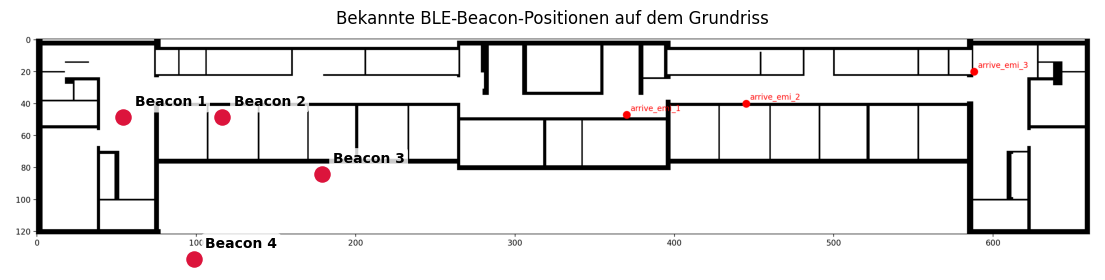

In [8]:
# create beacon karte
def plot_beacon_map(map_image, beacon_positions):
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.imshow(map_image)

    for beacon_id, (x, y) in beacon_positions.items():
        ax.scatter(
            x,
            y,
            s=180,
            color="crimson",
            edgecolor="white",
            linewidth=1.5,
            zorder=3,
        )
        ax.annotate(
            beacon_id,
            (x, y),
            xytext=(8, 8),
            textcoords="offset points",
            color="black",
            fontsize=10,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
            ),
        )

    ax.set_title("Bekannte BLE-Beacon-Positionen auf dem Grundriss")
    ax.axis("off")
    plt.show()


plot_beacon_map(map_image, BEACON_POSITIONS)

In [9]:
map_beacons = strongest_beacon[
    strongest_beacon["beacon_id"].isin(BEACON_POSITIONS)
].copy()

beacon_evidence = (
    map_beacons.groupby("beacon_id", as_index=False)
    .agg(
        strongest_count=("time_bin_s", "size"),
        median_strongest_rssi=("rssi_median", "median"),
        max_rssi=("rssi_median", "max"),
    )
)

beacon_evidence["x_px"] = beacon_evidence["beacon_id"].map(
    lambda beacon_id: BEACON_POSITIONS[beacon_id][0]
)

beacon_evidence["y_px"] = beacon_evidence["beacon_id"].map(
    lambda beacon_id: BEACON_POSITIONS[beacon_id][1]
)

display(beacon_evidence)

,beacon_id,strongest_count,median_strongest_rssi,max_rssi,x_px,y_px


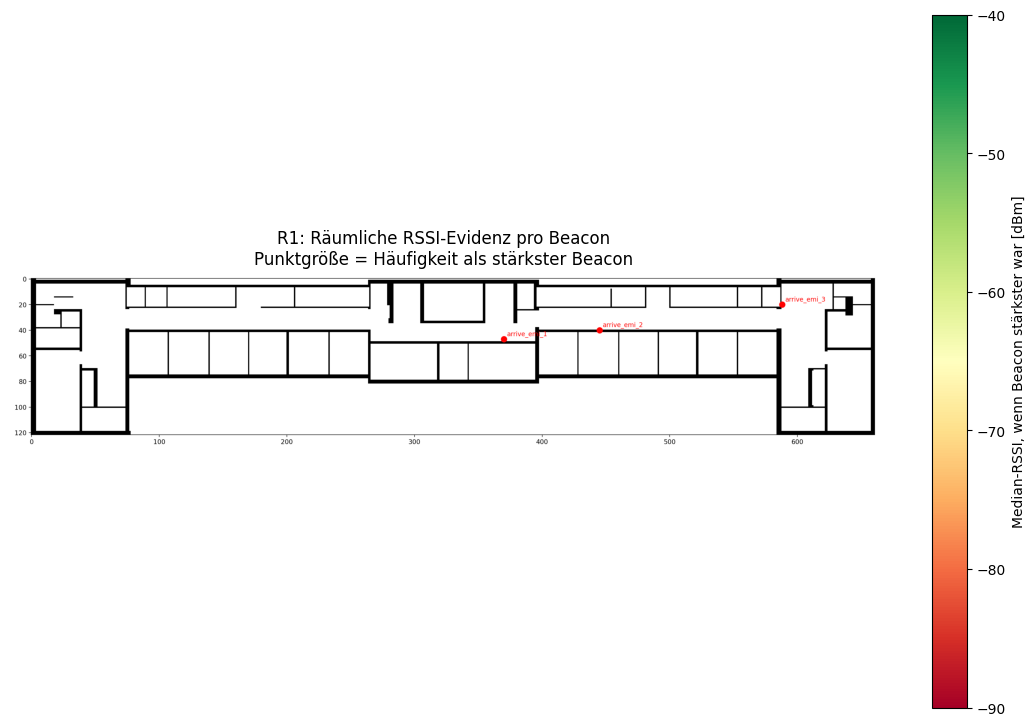

In [10]:
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(map_image)

scatter = ax.scatter(
    beacon_evidence["x_px"],
    beacon_evidence["y_px"],
    s=beacon_evidence["strongest_count"] * 20 + 120,
    c=beacon_evidence["median_strongest_rssi"],
    cmap="RdYlGn",
    vmin=-90,
    vmax=-40,
    edgecolor="black",
    linewidth=1.2,
    zorder=3,
)

for _, row in beacon_evidence.iterrows():
    ax.annotate(
        (
            f"{row['beacon_id']}\n"
            f"Median: {row['median_strongest_rssi']:.1f} dBm\n"
            f"Stärkster: {row['strongest_count']}x"
        ),
        (row["x_px"], row["y_px"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.85,
        ),
    )

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("Median-RSSI, wenn Beacon stärkster war [dBm]")

ax.set_title(
    f"{RUN_ID}: Räumliche RSSI-Evidenz pro Beacon\n"
    "Punktgröße = Häufigkeit als stärkster Beacon"
)
ax.axis("off")

plt.show()